In [1]:
!pip install /kaggle/input/rdkit-2025-3-3-cp311/rdkit-2025.3.3-cp311-cp311-manylinux_2_28_x86_64.whl
!pip install mordred --no-index --find-links=file:///kaggle/input/mordred-1-2-0-py3-none-any/
!pip install torch_geometric --no-index --find-links=file:/kaggle/input/torch-geometric-2-6-1-whl/torch_geometric-2.6.1-py3-none-any.whl

Processing /kaggle/input/rdkit-2025-3-3-cp311/rdkit-2025.3.3-cp311-cp311-manylinux_2_28_x86_64.whl
Looking in links: file:///kaggle/input/mordred-1-2-0-py3-none-any/
Processing /kaggle/input/mordred-1-2-0-py3-none-any/mordred-1.2.0-py3-none-any.whl
Processing /kaggle/input/mordred-1-2-0-py3-none-any/networkx-2.8.8-py3-none-any.whl (from mordred)
  Attempting uninstall: networkx
    Found existing installation: networkx 3.5
    Uninstalling networkx-3.5:
      Successfully uninstalled networkx-3.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires networkx>=3.0, but you have networkx 2.8.8 which is incompatible.
nx-cugraph-cu12 25.2.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have

In [2]:
import warnings
warnings.simplefilter(action='ignore')

import os
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GCNConv, GATConv, GraphConv, global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.data import Data, Batch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from collections import defaultdict
import matplotlib.pyplot as plt

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load data
train = pd.read_csv('/kaggle/input/neurips-open-polymer-prediction-2025/train.csv')
test = pd.read_csv('/kaggle/input/neurips-open-polymer-prediction-2025/test.csv')

Using device: cpu


In [3]:
def improved_tokenize_smiles(smiles):
    """Enhanced SMILES tokenization"""
    pattern = r'(\[[^\[\]]{1,10}\]|Br|Cl|[bcnops]|[BCNOFPSI]|[()=+\-#@:/\\]|\d+|\.)'
    tokens = re.findall(pattern, smiles)
    reconstructed = ''.join(tokens)
    remaining = smiles.replace(reconstructed, '')
    if remaining:
        tokens.extend(list(remaining))
    return tokens

class SMILESToGraph:
    """Convert SMILES strings to molecular graphs"""
    
    def __init__(self):
        # Atom feature mappings
        self.atom_types = ['C', 'N', 'O', 'S', 'P', 'F', 'Cl', 'Br', 'I', 'H', 'B', 'Si', 'Se', 'Te', 'As']
        self.atom_to_idx = {atom: idx for idx, atom in enumerate(self.atom_types)}
        self.atom_to_idx['UNK'] = len(self.atom_types)  # Unknown atom type
        
        # Bond type mappings
        self.bond_types = ['-', '=', '#', ':']  # single, double, triple, aromatic
        self.bond_to_idx = {bond: idx for idx, bond in enumerate(self.bond_types)}
        
        # Electronegativity values for atoms
        self.electronegativity = {
            'C': 2.55, 'N': 3.04, 'O': 3.44, 'S': 2.58, 'P': 2.19, 
            'F': 3.98, 'Cl': 3.16, 'Br': 2.96, 'I': 2.66, 'H': 2.20,
            'B': 2.04, 'Si': 1.90, 'Se': 2.55, 'Te': 2.1, 'As': 2.18
        }
        
        # Atomic masses
        self.atomic_masses = {
            'C': 12.01, 'N': 14.01, 'O': 16.00, 'S': 32.06, 'P': 30.97,
            'F': 19.00, 'Cl': 35.45, 'Br': 79.90, 'I': 126.90, 'H': 1.008,
            'B': 10.81, 'Si': 28.09, 'Se': 78.96, 'Te': 127.60, 'As': 74.92
        }
    
    def extract_atom_from_token(self, token):
        """Extract atom type from SMILES token"""
        if token in self.atom_types:
            return token
        elif len(token) >= 2 and token[:2] in self.atom_types:
            return token[:2]
        elif len(token) >= 1 and token[0] in self.atom_types:
            return token[0]
        elif token.startswith('[') and token.endswith(']'):
            # Handle bracketed atoms like [NH], [OH], etc.
            inner = token[1:-1]
            for atom in self.atom_types:
                if inner.startswith(atom):
                    return atom
        return 'UNK'
    
    def get_atom_features(self, atom_type, token):
        """Generate comprehensive atom features"""
        features = []
        
        # One-hot encoding for atom type
        atom_onehot = [0] * (len(self.atom_types) + 1)
        if atom_type in self.atom_to_idx:
            atom_onehot[self.atom_to_idx[atom_type]] = 1
        else:
            atom_onehot[self.atom_to_idx['UNK']] = 1
        features.extend(atom_onehot)
        
        # Electronegativity
        electronegativity = self.electronegativity.get(atom_type, 2.5)
        features.append(electronegativity)
        
        # Atomic mass (normalized)
        atomic_mass = self.atomic_masses.get(atom_type, 12.0) / 100.0
        features.append(atomic_mass)
        
        # Is aromatic (lowercase in SMILES)
        is_aromatic = 1 if token.islower() and token.isalpha() else 0
        features.append(is_aromatic)
        
        # Is in bracket (special notation)
        is_bracketed = 1 if token.startswith('[') and token.endswith(']') else 0
        features.append(is_bracketed)
        
        # Charge information (simplified)
        charge = 0
        if '+' in token:
            charge = token.count('+')
        elif '-' in token:
            charge = -token.count('-')
        features.append(charge)
        
        return features
    
    def smiles_to_graph(self, smiles):
        """Convert SMILES to molecular graph"""
        tokens = improved_tokenize_smiles(smiles)
        
        if len(tokens) == 0:
            # Return minimal graph for empty SMILES
            node_features = torch.zeros(1, len(self.atom_types) + 6)  # +6 for additional features
            edge_index = torch.empty(2, 0, dtype=torch.long)
            edge_attr = torch.empty(0, len(self.bond_types), dtype=torch.float)
            return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr)
        
        # Create atom features
        node_features = []
        atom_stack = []  # For handling parentheses
        ring_dict = defaultdict(list)  # For handling rings
        
        for i, token in enumerate(tokens):
            if token == '(':
                atom_stack.append(len(node_features) - 1)
                continue
            elif token == ')':
                if atom_stack:
                    atom_stack.pop()
                continue
            elif token.isdigit():
                # Ring closure
                ring_num = int(token)
                ring_dict[ring_num].append(len(node_features) - 1)
                continue
            elif token in ['=', '#', ':', '-']:
                # Bond tokens - will be handled in edge creation
                continue
            
            # Extract atom type and create features
            atom_type = self.extract_atom_from_token(token)
            atom_feats = self.get_atom_features(atom_type, token)
            node_features.append(atom_feats)
        
        if len(node_features) == 0:
            # Fallback for problematic SMILES
            node_features = [[1] + [0] * (len(self.atom_types) + 5)]  # Carbon atom
        
        node_features = torch.tensor(node_features, dtype=torch.float)
        
        # Create edges (simplified approach)
        edges = []
        edge_attributes = []
        
        # Sequential bonds
        for i in range(len(node_features) - 1):
            edges.append([i, i + 1])
            edges.append([i + 1, i])  # Undirected graph
            
            # Default single bond
            bond_feat = [1, 0, 0, 0]  # single bond
            edge_attributes.extend([bond_feat, bond_feat])
        
        # Ring closure bonds
        for ring_bonds in ring_dict.values():
            if len(ring_bonds) >= 2:
                for i in range(0, len(ring_bonds), 2):
                    if i + 1 < len(ring_bonds):
                        atom1, atom2 = ring_bonds[i], ring_bonds[i + 1]
                        edges.append([atom1, atom2])
                        edges.append([atom2, atom1])
                        
                        bond_feat = [1, 0, 0, 0]  # single bond
                        edge_attributes.extend([bond_feat, bond_feat])
        
        # Handle bond types from SMILES
        bond_indicators = {'=': [0, 1, 0, 0], '#': [0, 0, 1, 0], ':': [0, 0, 0, 1]}
        
        # Update edge attributes based on bond symbols in SMILES
        for i, token in enumerate(tokens):
            if token in bond_indicators and len(edge_attributes) > i * 2:
                if i * 2 < len(edge_attributes):
                    edge_attributes[i * 2] = bond_indicators[token]
                if i * 2 + 1 < len(edge_attributes):
                    edge_attributes[i * 2 + 1] = bond_indicators[token]
        
        if len(edges) == 0:
            # Self-loop for single atom
            edges = [[0, 0]]
            edge_attributes = [[1, 0, 0, 0]]
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attributes, dtype=torch.float)
        
        return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr)

class MolecularDataset(Dataset):
    """Dataset for molecular graphs and targets"""
    
    def __init__(self, smiles_list, targets=None, graph_converter=None):
        self.smiles_list = smiles_list
        self.targets = targets
        self.graph_converter = graph_converter or SMILESToGraph()
        
        # Pre-compute graphs
        self.graphs = []
        for smiles in smiles_list:
            try:
                graph = self.graph_converter.smiles_to_graph(smiles)
                self.graphs.append(graph)
            except Exception as e:
                print(f"Error processing SMILES {smiles}: {e}")
                # Create a dummy graph
                dummy_graph = Data(x=torch.ones(1, 22), edge_index=torch.tensor([[0], [0]]), 
                                 edge_attr=torch.ones(1, 4))
                self.graphs.append(dummy_graph)
    
    def __len__(self):
        return len(self.smiles_list)
    
    def __getitem__(self, idx):
        graph = self.graphs[idx]
        
        if self.targets is not None:
            target = torch.tensor(self.targets[idx], dtype=torch.float)
            return graph, target
        
        return graph


In [4]:
class AdvancedGNN(nn.Module):
    """Advanced Graph Neural Network with multiple layers and pooling"""
    
    def __init__(self, input_dim, hidden_dim=128, output_dim=1, num_layers=4, dropout=0.2):
        super(AdvancedGNN, self).__init__()
        
        self.num_layers = num_layers
        self.dropout = dropout
        
        # Graph convolution layers
        self.convs = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        
        # First layer
        self.convs.append(GCNConv(input_dim, hidden_dim))
        self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
        
        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
        
        # Last conv layer
        if num_layers > 1:
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
        
        # Attention mechanism
        self.attention = GATConv(hidden_dim, hidden_dim // 4, heads=4, dropout=dropout)
        self.attention_norm = nn.BatchNorm1d(hidden_dim)
        
        # Final prediction layers
        self.fc_layers = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim * 2),  # *3 for mean, max, add pooling
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Apply graph convolutions
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Apply attention
        x = self.attention(x, edge_index)
        x = self.attention_norm(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Global pooling
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x_add = global_add_pool(x, batch)
        
        # Concatenate different pooling results
        x = torch.cat([x_mean, x_max, x_add], dim=1)
        
        # Final prediction
        x = self.fc_layers(x)
        
        return x

In [5]:
def train_gnn_model(train_loader, val_loader, input_dim, model_name, epochs=200):
    """Train a GNN model"""
    model = AdvancedGNN(input_dim=input_dim, hidden_dim=128, output_dim=1, 
                       num_layers=4, dropout=0.3).to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                          factor=0.7, patience=15, verbose=True)
    criterion = nn.MSELoss()
    
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 30
    
    train_losses = []
    val_losses = []
    
    print(f"Training {model_name} model...")
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch_data, batch_target in train_loader:
            batch_data = batch_data.to(device)
            batch_target = batch_target.to(device)
            
            optimizer.zero_grad()
            output = model(batch_data)
            loss = criterion(output.squeeze(), batch_target)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_data, batch_target in val_loader:
                batch_data = batch_data.to(device)
                batch_target = batch_target.to(device)
                
                output = model(batch_data)
                loss = criterion(output.squeeze(), batch_target)
                val_loss += loss.item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), f'best_gnn_{model_name}.pth')
        else:
            patience_counter += 1
        
        if epoch % 20 == 0:
            print(f'Epoch {epoch:03d}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch}')
            break
    
    # Load best model
    model.load_state_dict(torch.load(f'best_gnn_{model_name}.pth'))
    
    return model, train_losses, val_losses

Converting SMILES to graphs...
Input dimension: 21
['Tg', 'FFV', 'Tc', 'Density', 'Rg']

Training model for Tg
                                                 SMILES          Tg
40                           *NC(C)C(=O)NCC(=O)NCC(*)=O  208.639749
57                                     *CCCCCCSSCCCCSS*  -41.266724
63                                        *C=CCCCCCCCC*  -17.282022
108   *CCCCCCCCCCOC(=O)c1ccc(C(=O)NCCNC(=O)c2ccc(C(=...    4.250403
123   *c1nc2cc3sc(-c4cc(OCCCCCC)c(*)cc4OCCCCCC)nc3cc2s1  168.526313
...                                                 ...         ...
7863   *Nc1cc(SCCC#N)c(NC(=O)c2cccc(C(*)=O)c2)cc1SCCC#N   38.160660
7868             *c1ccc(C2C(C(=O)OCC)C(*)C2C(=O)OCC)cc1  164.322463
7889  *Oc1ccc(C=Cc2ccc(C=Cc3ccc(OC(=O)CCCCCCCCC(*)=O...   35.475235
7911                     *CC(*)C(=O)OCC1(C)COC(C)(C)OC1   95.741049
7971                                   *C=C(*)c1ccccc1C  261.662355

[511 rows x 2 columns]
Training samples: 434
Validation samples: 77
Trai

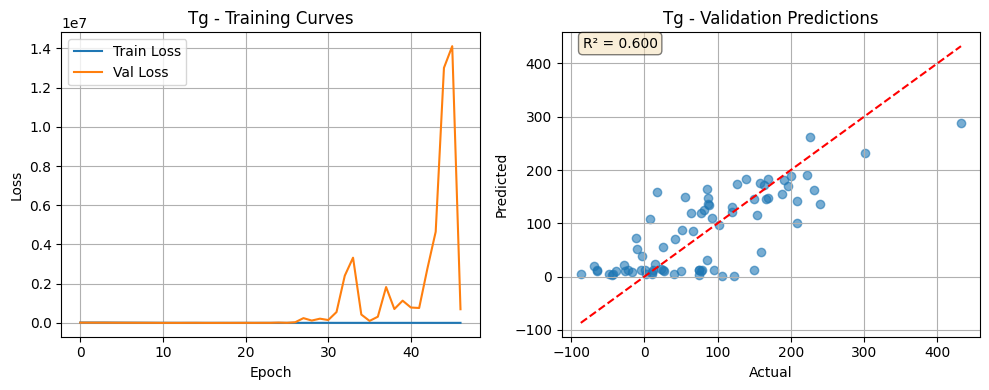


Training model for FFV
                                                 SMILES       FFV
0                            *CC(*)c1ccccc1C(=O)OCCCCCC  0.374645
1     *Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...  0.370410
2     *Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...  0.378860
3     *Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...  0.387324
4     *Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...  0.355470
...                                                 ...       ...
7967  *CCOC(=O)c1ccc(C(C#N)=C(c2ccc(OC)cc2)N2CCC(*)C...  0.385608
7968       *Oc1cc(CCCCCCCC)cc(OC(=O)c2cccc(C(*)=O)c2)c1  0.367498
7969  *C(=O)OCCN(CCOC(=O)c1ccc2c(c1)C(=O)N(c1cccc(N3...  0.353280
7970  *c1cc(C(=O)NCCCCCCCC)cc(N2C(=O)c3ccc(-c4ccc5c(...  0.369411
7972  *c1ccc(OCCCCCCCCCCCOC(=O)CCCCC(=O)OCCCCCCCCCCC...  0.374049

[7030 rows x 2 columns]
Training samples: 5975
Validation samples: 1055
Training FFV model...
Epoch 000: Train Loss: 0.0384, Val Loss: 0.2441
Epoch 020: Train Loss: 0.0005, Val Loss: 

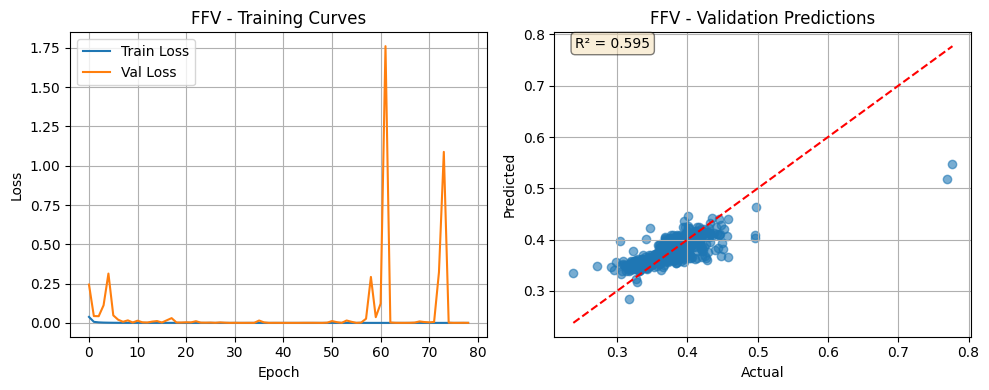


Training model for Tc
                                                 SMILES        Tc
0                            *CC(*)c1ccccc1C(=O)OCCCCCC  0.205667
10    *c1ccc(-c2ccc3c(c2)C(CCCCCCC#N)(CCCCCCC#N)c2cc...  0.487000
11                       *CC(*)c1ccc(C(=O)O)c(C(=O)O)c1  0.171000
31                              *CCCCCNC(=O)CCCCC(=O)N*  0.327000
34             *CCCCCCCCCCCCCCCCCCNC(=O)NCCCCCCNC(=O)N*  0.383000
...                                                 ...       ...
7899                        *CCN(*)C(=O)CCCCCCCCCCCCCCC  0.336000
7905                                    *CC(*)c1ccccc1F  0.174667
7943                                    *CC(*)C1CC=CCC1  0.180750
7944                                           *CC(*)Cl  0.139000
7952                  *CCCC(=O)NCc1ccc(CNC(=O)CCCO*)cc1  0.259000

[737 rows x 2 columns]
Training samples: 626
Validation samples: 111
Training Tc model...
Epoch 000: Train Loss: 0.0796, Val Loss: 0.0326
Epoch 020: Train Loss: 0.0030, Val Loss: 0.015

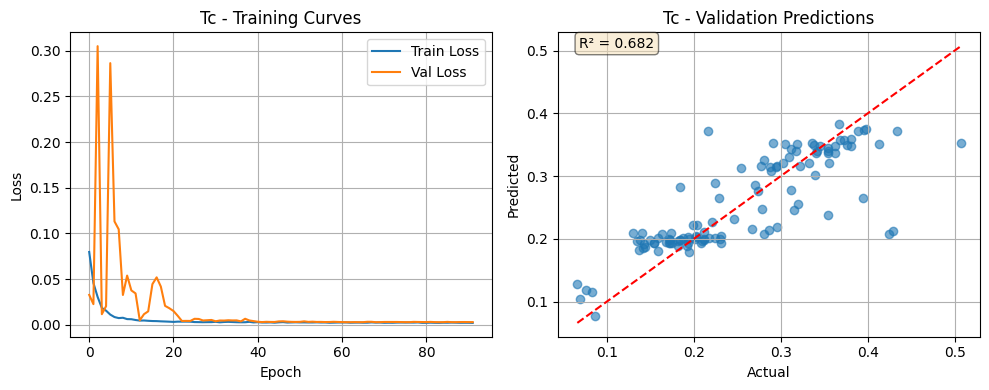


Training model for Density
                                                 SMILES   Density
10    *c1ccc(-c2ccc3c(c2)C(CCCCCCC#N)(CCCCCCC#N)c2cc...  0.901123
11                       *CC(*)c1ccc(C(=O)O)c(C(=O)O)c1  1.184354
46                                *CC(*)C(=O)Oc1ccccc1C  1.061864
64                                 *CC(*)C(=O)Oc1ccccc1  1.109389
88                                     *CC(C)S(*)(=O)=O  1.293315
...                                                 ...       ...
7943                                    *CC(*)C1CC=CCC1  0.842083
7944                                           *CC(*)Cl  1.263489
7945                                      *CCCCCC(=O)O*  1.002696
7952                  *CCCC(=O)NCc1ccc(CNC(=O)CCCO*)cc1  1.107946
7957   *Oc1ccc(C2(c3ccc(OC(*)=O)cc3)CC(C)CC(C)(C)C2)cc1  0.982602

[613 rows x 2 columns]
Training samples: 521
Validation samples: 92
Training Density model...
Epoch 000: Train Loss: 0.4742, Val Loss: 0.2162
Epoch 020: Train Loss: 0.0306, Val Lo

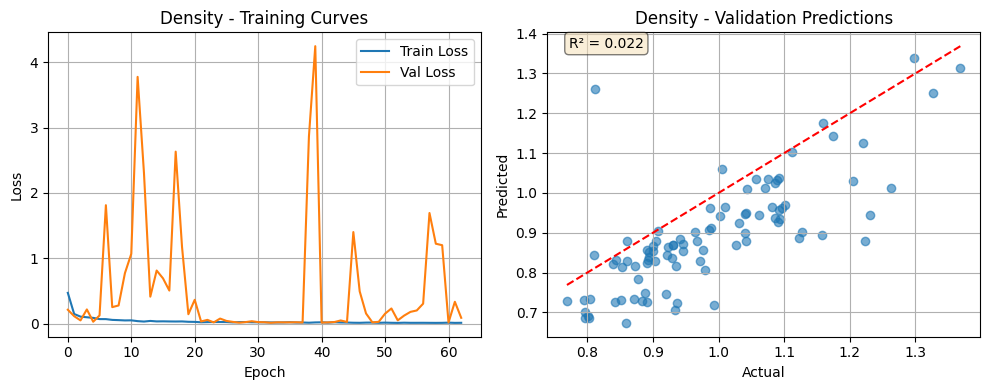


Training model for Rg
                                                 SMILES         Rg
10    *c1ccc(-c2ccc3c(c2)C(CCCCCCC#N)(CCCCCCC#N)c2cc...  28.682441
11                       *CC(*)c1ccc(C(=O)O)c(C(=O)O)c1  13.534248
37                                             *CC(*)CC  13.872913
46                                *CC(*)C(=O)Oc1ccccc1C  12.737463
64                                 *CC(*)C(=O)Oc1ccccc1  13.435339
...                                                 ...        ...
7943                                    *CC(*)C1CC=CCC1  12.703534
7944                                           *CC(*)Cl  21.121972
7945                                      *CCCCCC(=O)O*  18.833676
7952                  *CCCC(=O)NCc1ccc(CNC(=O)CCCO*)cc1  20.187782
7957   *Oc1ccc(C2(c3ccc(OC(*)=O)cc3)CC(C)CC(C)(C)C2)cc1  17.755820

[614 rows x 2 columns]
Training samples: 521
Validation samples: 93
Training Rg model...
Epoch 000: Train Loss: 272.2684, Val Loss: 286.2380
Epoch 020: Train Loss: 20.2423,

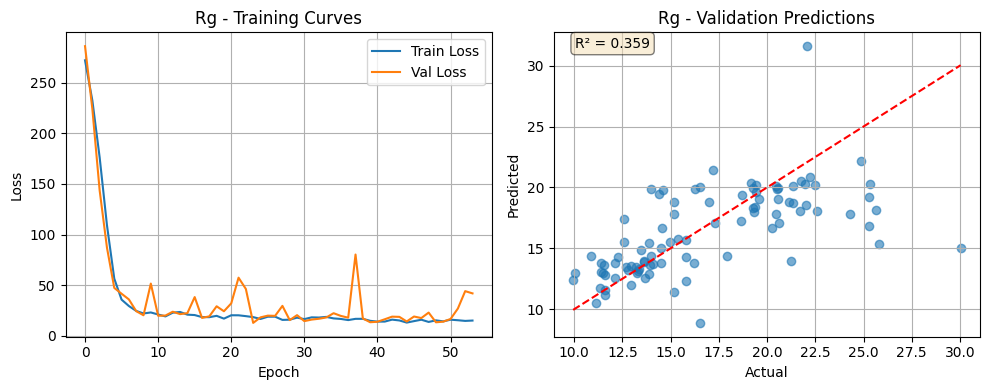

In [6]:
def collate_fn(batch):
    """Custom collate function for DataLoader"""
    if len(batch[0]) == 2:  # Training data with targets
        graphs, targets = zip(*batch)
        batch_graph = Batch.from_data_list(graphs)
        batch_targets = torch.stack(targets)
        return batch_graph, batch_targets
    else:  # Test data without targets
        graphs = batch
        batch_graph = Batch.from_data_list(graphs)
        return batch_graph

# Initialize graph converter
graph_converter = SMILESToGraph()

# Create datasets
print("Converting SMILES to graphs...")

# Prepare training data
train_cleaned = train
target_columns = ['Tg', 'FFV', 'Tc', 'Density', 'Rg']

# Create test dataset
test_dataset = MolecularDataset(test['SMILES'].tolist(), graph_converter=graph_converter)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

# Get input dimension from first graph
sample_graph = test_dataset[0]
input_dim = sample_graph.x.shape[1]
print(f"Input dimension: {input_dim}")

# Train models for each target
predictions = {}
models = {}
print(target_columns)
for target in target_columns:
    print(f"\n{'='*50}")
    print(f"Training model for {target}")
    print(f"{'='*50}")
    
    # Prepare target-specific data
    target_train = train_cleaned[['SMILES', target]].dropna()
    print(target_train)
    if len(target_train) < 50:  # Skip if too few samples
        print(f"Skipping {target} due to insufficient data ({len(target_train)} samples)")
        continue
    
    # Create dataset
    train_dataset = MolecularDataset(target_train['SMILES'].tolist(), 
                                   target_train[target].values, 
                                   graph_converter=graph_converter)
    print(train_dataset)
    # Split data
    train_indices, val_indices = train_test_split(
        range(len(train_dataset)), test_size=0.15, random_state=42
    )
    
    train_subset = torch.utils.data.Subset(train_dataset, train_indices)
    val_subset = torch.utils.data.Subset(train_dataset, val_indices)
    
    # Create data loaders
    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, collate_fn=collate_fn)
    
    print(f"Training samples: {len(train_subset)}")
    print(f"Validation samples: {len(val_subset)}")
    
    # Train model
    model, train_losses, val_losses = train_gnn_model(
        train_loader, val_loader, input_dim, target, epochs=300
    )
    
    models[target] = model
    
    # Make predictions on test set
    model.eval()
    test_predictions = []
    
    with torch.no_grad():
        for batch_data in test_loader:
            batch_data = batch_data.to(device)
            output = model(batch_data)
            test_predictions.extend(output.squeeze().cpu().numpy())
    
    predictions[target] = test_predictions
    
    print(f"Completed training for {target}")
    
    # Plot training curves
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title(f'{target} - Training Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Validation predictions vs actual
    val_predictions = []
    val_actuals = []
    
    with torch.no_grad():
        for batch_data, batch_target in val_loader:
            batch_data = batch_data.to(device)
            output = model(batch_data)
            val_predictions.extend(output.squeeze().cpu().numpy())
            val_actuals.extend(batch_target.cpu().numpy())
    
    plt.subplot(1, 2, 2)
    plt.scatter(val_actuals, val_predictions, alpha=0.6)
    plt.plot([min(val_actuals), max(val_actuals)], [min(val_actuals), max(val_actuals)], 'r--')
    plt.title(f'{target} - Validation Predictions')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(True)
    
    # Calculate R²
    r2 = r2_score(val_actuals, val_predictions)
    plt.text(0.05, 0.95, f'R² = {r2:.3f}', transform=plt.gca().transAxes, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(f'gnn_{target}_training.png', dpi=150, bbox_inches='tight')
    plt.show()

In [7]:
# Create submission file
print("\n" + "="*50)
print("Creating submission file...")
print("="*50)

submission_data = {'id': test['id']}

for target in target_columns:
    if target in predictions:
        submission_data[target] = predictions[target]
        print(f"{target}: {len(predictions[target])} predictions")
        print(f"  Range: [{min(predictions[target]):.3f}, {max(predictions[target]):.3f}]")
        print(f"  Mean: {np.mean(predictions[target]):.3f} ± {np.std(predictions[target]):.3f}")
    else:
        # Use mean values from training data if model failed
        mean_val = train[target].mean() if not train[target].isna().all() else 0
        submission_data[target] = [mean_val] * len(test)
        print(f"{target}: Using mean value {mean_val:.3f} (model failed)")

submission_df = pd.DataFrame(submission_data)

# Save submission
submission_df.to_csv('submission.csv', index=False)
print(f"\nSubmission saved as 'submission.csv'")
print(f"Submission shape: {submission_df.shape}")

# Display first few predictions
print("\nFirst 10 predictions:")
print(submission_df.head(10))

# Save models
print("\nSaving trained models...")
for target, model in models.items():
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_class': 'AdvancedGNN',
        'input_dim': input_dim,
        'target': target
    }, f'gnn_model_{target}.pth')

print("All models saved successfully!")


Creating submission file...
Tg: 3 predictions
  Range: [146.435, 160.382]
  Mean: 154.913 ± 6.079
FFV: 3 predictions
  Range: [0.367, 0.388]
  Mean: 0.375 ± 0.009
Tc: 3 predictions
  Range: [0.210, 0.286]
  Mean: 0.241 ± 0.033
Density: 3 predictions
  Range: [0.857, 1.015]
  Mean: 0.930 ± 0.065
Rg: 3 predictions
  Range: [19.921, 45.871]
  Mean: 28.615 ± 12.202

Submission saved as 'submission.csv'
Submission shape: (3, 6)

First 10 predictions:
           id          Tg       FFV        Tc   Density         Rg
0  1109053969  157.921524  0.367149  0.210032  0.920081  19.921160
1  1422188626  160.382339  0.387659  0.227653  1.014563  20.051916
2  2032016830  146.434586  0.369974  0.286191  0.856761  45.871220

Saving trained models...
All models saved successfully!
